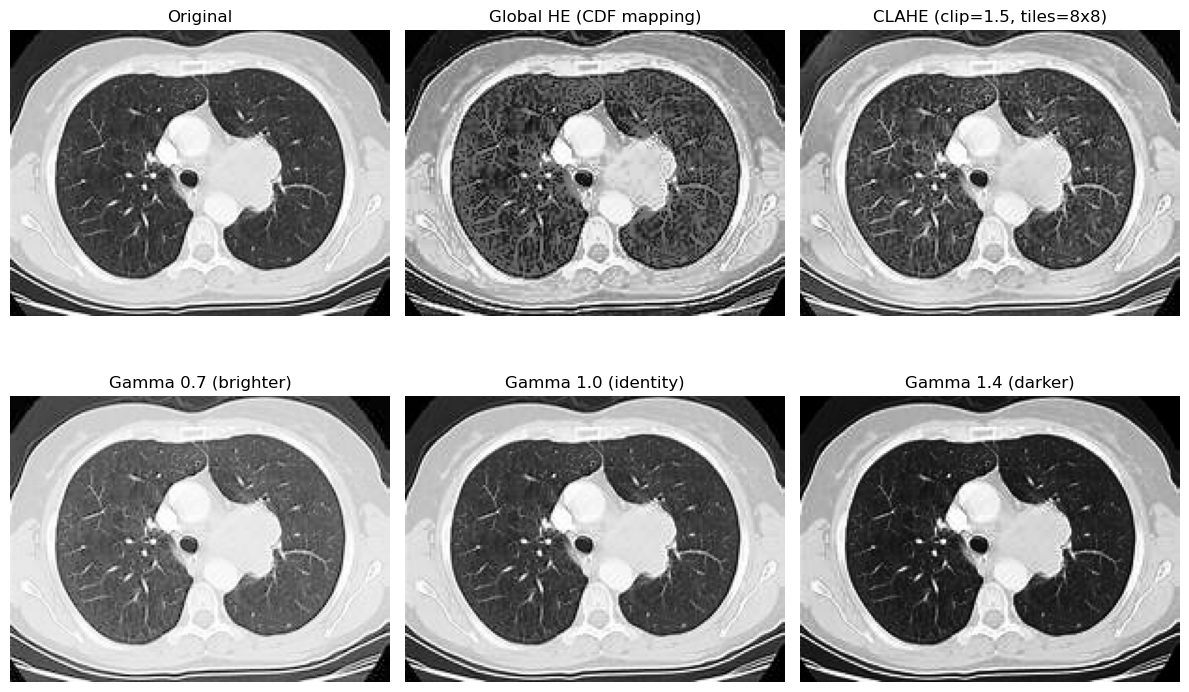

In [1]:
# Q1. Reproduce & compare three enhancement strategies
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# 0) Load image (grayscale)

IMG_PATH = "CT_Image.jpg" 

img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Could not load image at: {IMG_PATH}")

# Ensure uint8 (0..255)
if img.dtype != np.uint8:
   img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# -----------------------------
# 1) Global Histogram Equalization (CDF mapping)
# -----------------------------
# This is effectively CDF mapping on intensity levels for uint8 images
he = cv2.equalizeHist(img)

# -----------------------------
# 2) CLAHE (conservative parameters)
# -----------------------------
# Conservative = smaller clipLimit and moderate tileGridSize
clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
clahe_img = clahe.apply(img)

# -----------------------------
# 3) Gamma sweep (>=3 settings)
# -----------------------------
def gamma_correction_uint8(image_uint8, gamma: float) -> np.ndarray:
# Normalize to [0,1], apply power law, back to uint8
   x = image_uint8.astype(np.float32) / 255.0
   y = np.power(x, gamma)
   return np.clip(y * 255.0, 0, 255).astype(np.uint8)

gamma_vals = [0.7, 1.0, 1.4] # 3 settings
gamma_imgs = [gamma_correction_uint8(img, g) for g in gamma_vals]

# -----------------------------
# 4) Save outputs (optional but useful for submission)
# -----------------------------
cv2.imwrite("CT_original.png", img)
cv2.imwrite("CT_global_HE.png", he)
cv2.imwrite("CT_CLAHE.png", clahe_img)
for g, gi in zip(gamma_vals, gamma_imgs):
   cv2.imwrite(f"CT_gamma_{g}.png", gi)

# -----------------------------
# 5) Figure panel (original + methods)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

panels = [
(img, "Original"),
(he, "Global HE (CDF mapping)"),
(clahe_img, "CLAHE (clip=1.5, tiles=8x8)"),
    
(gamma_imgs[0], f"Gamma {gamma_vals[0]} (brighter)"),
(gamma_imgs[1], f"Gamma {gamma_vals[1]} (identity)"),
(gamma_imgs[2], f"Gamma {gamma_vals[2]} (darker)")
]

for ax, (im, title) in zip(axes, panels):
   ax.imshow(im, cmap="gray")
   ax.set_title(title)
   ax.axis("off")

plt.tight_layout()
plt.savefig("CT_figure_panel.png", dpi=200)
plt.show()


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Otsu threshold: 136.0
Otsu area fraction: 0.5096
K-means area fraction: 0.5096


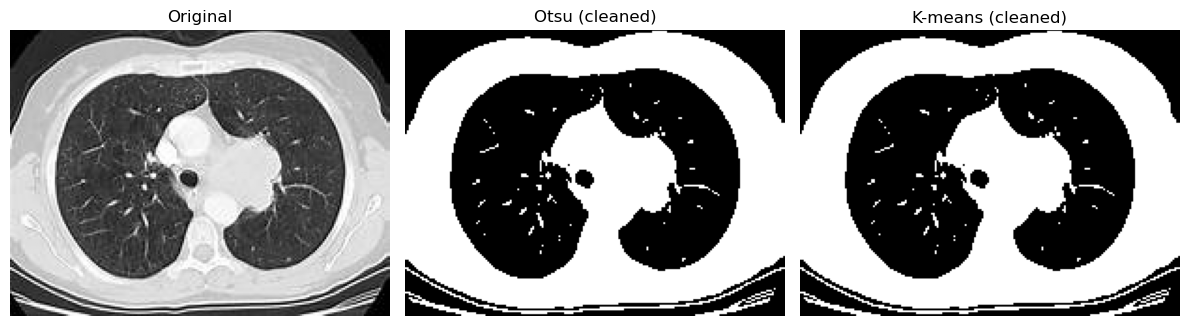

In [2]:
# Q2. Segmentation comparison: Otsu vs K-means
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy import ndimage as ndi

# -------------------------------------------------
# Load grayscale image
# -------------------------------------------------
img = cv2.imread("CT_Image.jpg", cv2.IMREAD_GRAYSCALE)

# -------------------------------------------------
# 1) OTSU THRESHOLDING
# -------------------------------------------------
otsu_thresh, otsu_mask = cv2.threshold(
img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# -------------------------------------------------
# 2) K-MEANS SEGMENTATION (K=2, 5 replicates)
# -------------------------------------------------
pixels = img.reshape(-1, 1).astype(np.float32)

kmeans = KMeans(n_clusters=2, n_init=5, random_state=0)
labels = kmeans.fit_predict(pixels)

kmeans_mask = labels.reshape(img.shape)

# Make sure brighter cluster = 1
if np.mean(img[kmeans_mask == 0]) > np.mean(img[kmeans_mask == 1]):
   kmeans_mask = 1 - kmeans_mask

   kmeans_mask = (kmeans_mask * 255).astype(np.uint8)

# -------------------------------------------------
# 3) POST-PROCESSING (remove small fragments)
# -------------------------------------------------
def remove_small_objects(mask, min_size=500):
   labeled, num = ndi.label(mask)
   sizes = ndi.sum(mask, labeled, range(num + 1))
   mask_clean = mask.copy()
   for i in range(1, num + 1):
      if sizes[i] < min_size:
        mask_clean[labeled == i] = 0
        return mask_clean

otsu_clean = remove_small_objects(otsu_mask)
kmeans_clean = remove_small_objects(kmeans_mask)

# -------------------------------------------------
# 4) QUANTITATIVE SUMMARIES
# -------------------------------------------------
otsu_area_fraction = np.sum(otsu_clean > 0) / otsu_clean.size
kmeans_area_fraction = np.sum(kmeans_clean > 0) / kmeans_clean.size

print("Otsu threshold:", otsu_thresh)
print("Otsu area fraction:", round(otsu_area_fraction, 4))
print("K-means area fraction:", round(kmeans_area_fraction, 4))

# -------------------------------------------------
# 5) SHOW RESULTS
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(otsu_clean, cmap='gray')
axes[1].set_title("Otsu (cleaned)")
axes[1].axis("off")

axes[2].imshow(kmeans_clean, cmap='gray')
axes[2].set_title("K-means (cleaned)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

maxAbs difference: 1230.000000
RMSE difference: 174.749908


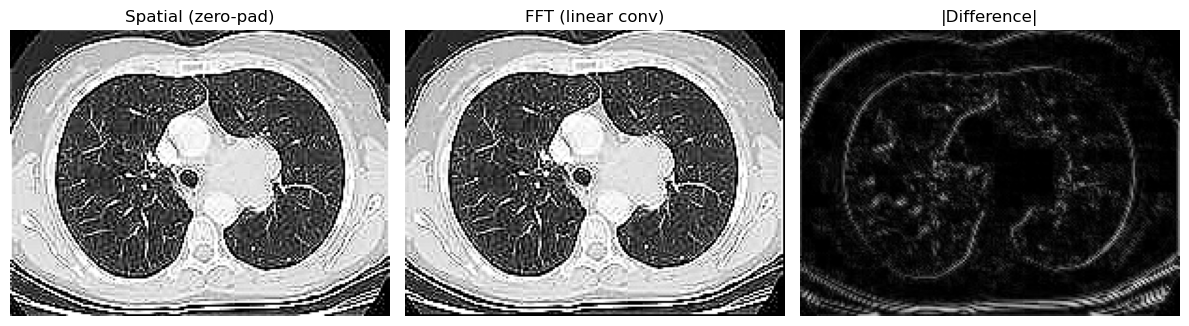

In [3]:
# Q3. Frequency-domain filtering equivalence experiment
import numpy as np
import matplotlib.pyplot as plt

# 1) Choose a small kernel / PSF (sharpening)
psf = np.array([[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]], dtype=np.float32)

kh, kw = psf.shape
pad_h, pad_w = kh - 1, kw - 1

# 2) Spatial-domain filtering with an explicitly stated boundary rule
# Boundary rule: ZERO padding (constant 0)
try:
   import cv2
   spatial = cv2.filter2D(img.astype(np.float32), ddepth=-1, kernel=psf,
   borderType=cv2.BORDER_CONSTANT)
except Exception:
   # Fallback: pure NumPy spatial convolution (slower but no extra deps)
   x = img.astype(np.float32)
   xpad = np.pad(x, ((kh//2, kh//2), (kw//2, kw//2)), mode="constant", constant_values=0)
   spatial = np.zeros_like(x, dtype=np.float32)
   for i in range(spatial.shape[0]):
      for j in range(spatial.shape[1]):
         patch = xpad[i:i+kh, j:j+kw]
         spatial[i, j] = np.sum(patch * psf)

# 3) FFT-domain filtering (linear convolution):
# - pad image to (H+kh-1, W+kw-1)
# - PSF->OTF alignment (centered PSF)
# - IFFT then crop back to original size
x = img.astype(np.float32)
H, W = x.shape
Hp, Wp = H + pad_h, W + pad_w

# zero-pad image
x_pad = np.zeros((Hp, Wp), dtype=np.float32)
x_pad[:H, :W] = x

# PSF -> OTF:
# place PSF at top-left, then circularly shift so PSF center moves to (0,0)
otf = np.zeros((Hp, Wp), dtype=np.float32)
otf[:kh, :kw] = psf
otf = np.roll(otf, shift=-(kh//2), axis=0)
otf = np.roll(otf, shift=-(kw//2), axis=1)

X = np.fft.fft2(x_pad)
Hf = np.fft.fft2(otf)
Y = X * Hf
y_full = np.fft.ifft2(Y).real # linear-conv result in padded domain

# crop to original size (same as "valid" alignment for same-size output)
r0, c0 = kh//2, kw//2
fft_out = y_full[r0:r0+H, c0:c0+W]

# 4) Difference image + metrics
diff = spatial - fft_out
maxAbs = float(np.max(np.abs(diff)))
rmse = float(np.sqrt(np.mean(diff**2)))

print(f"maxAbs difference: {maxAbs:.6f}")
print(f"RMSE difference: {rmse:.6f}")

# 5) Visual comparison panel
def clip8(a):
   return np.clip(a, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(clip8(spatial), cmap="gray"); plt.title("Spatial (zero-pad)"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(clip8(fft_out), cmap="gray"); plt.title("FFT (linear conv)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(np.abs(diff), cmap="gray"); plt.title("|Difference|"); plt.axis("off")
plt.tight_layout()
plt.show()